This is a demo of the capabilities of MPHvect to map Mixup Barcodes (Hubert Wagner, et. al. 2026) to vectors in ell_1. MPHvect is an implementation of the methods described in "A Schauder Basis for Multiparameter Persistence and Persitsence Variants": Peter Bubenik & Zachariah Ross, 2025.Begin by installing required packages

In [1]:
!pip install git+https://github.com/ZachTRoss/MPHvect.git


!pip install chromatic_tda
#!pip install ripser
!pip install persim
#!pip install scikit-learn

#MPHvect works faster with numba installed
!pip install numba
!pip install nbformat

  Cloning https://github.com/ZachTRoss/MPHvect.git to /tmp/pip-req-build-__l_0sdk
  Running command git clone --filter=blob:none --quiet https://github.com/ZachTRoss/MPHvect.git /tmp/pip-req-build-__l_0sdk
  Resolved https://github.com/ZachTRoss/MPHvect.git to commit e9225adde49d8224f4078d57a9abb2a195e3ff9a
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 24.9 MB/s eta 0:00:00
  Created wheel for MPHvect: filename=MPHvect-0.1.0-py3-none-any.whl size=10003 sha256=84bef83cd07b04c133ec703fa7e1b085f2a653c108025f62ebead1686d1ac32c
  Stored in directory: /tmp/pip-ephem-wheel-cache-dix8n_i3/wheels/16/a7/37/f7d75b3a040fb4073e527243d839bd02415932158eb3594cb9
Successfully built MPHvect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.9 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=af924cb43105f290e66e43c0c922e869ffec12702dfc04e9f032f9f38307cdc8
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 74.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chromatic-tda 1.1.8 requires numpy<3.0,>=2.1, but you have numpy 2.0.2 which is incompatible.


In [1]:
import numba
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D


#from ripser import ripser
#from persim import plot_diagrams
#import itertools
from chromatic_tda import ChromaticAlphaComplex
import random
import chromatic_tda as chro
from persim import PersLandscapeApprox



import sys, math




from MPHvect.method import*
from MPHvect.SVM_functions import*

#import glob
import gc
#import os
#import IPython
#import subprocess

import gudhi as gd
#from gudhi.representations import Landscape
from plotly.subplots import make_subplots



First we define sampling functions.

In [2]:
#The following defines two methods of sampling pairs of data sets. The first method samples from a torus and an ellipsoid having common centers.
#The second samples the same, but with the ellipsoid shifted away from the torus.

def random_rotation_matrix():
    u1, u2, u3 = np.random.rand(3)

    q1 = np.sqrt(1 - u1) * np.sin(2 * np.pi * u2)
    q2 = np.sqrt(1 - u1) * np.cos(2 * np.pi * u2)
    q3 = np.sqrt(u1) * np.sin(2 * np.pi * u3)
    q4 = np.sqrt(u1) * np.cos(2 * np.pi * u3)

    # Quaternion to rotation matrix
    R = np.array([
        [1 - 2*(q3**2 + q4**2), 2*(q2*q3 - q1*q4),     2*(q2*q4 + q1*q3)],
        [2*(q2*q3 + q1*q4),     1 - 2*(q2**2 + q4**2), 2*(q3*q4 - q1*q2)],
        [2*(q2*q4 - q1*q3),     2*(q3*q4 + q1*q2),     1 - 2*(q2**2 + q3**2)]
    ])
    return R



def sample_ellipsoid(n, radii):
    """
    radii = (a, b, c)
    """
    x = np.random.normal(size=(n, 3))
    x /= np.linalg.norm(x, axis=1, keepdims=True)
    x *= np.random.rand(n, 1) ** (1/3)  # uniform in volume
    return x * np.array(radii)



def sample_torus(n, R, r):
    """
    R = major radius
    r = minor radius
    """
    theta = 2 * np.pi * np.random.rand(n)
    phi = 2 * np.pi * np.random.rand(n)

    x = (R + r * np.cos(phi)) * np.cos(theta)
    y = (R + r * np.cos(phi)) * np.sin(theta)
    z = r * np.sin(phi)

    return np.column_stack([x, y, z])



def sample_wrapped_classes(
    n_ellipse=500,
    n_torus=500,
    ellipsoid_radii=(1.0, 0.6, 0.4),
    torus_radius=0.9,
    torus_thickness=0.15,
    shift_ellipsoid=False
):


    ellipse_pts = sample_ellipsoid(n_ellipse, ellipsoid_radii)


    max_cross_section = max(ellipsoid_radii[0], ellipsoid_radii[1], ellipsoid_radii[2])
    torus_R =  torus_radius
    torus_r = torus_thickness

    torus_pts = sample_torus(n_torus, torus_R, torus_r)

    R = random_rotation_matrix()
    ellipse_pts = ellipse_pts @ R.T
    R = random_rotation_matrix()
    torus_pts = torus_pts @ R.T

    if shift_ellipsoid==True:
      axis = R @ np.array([0.0, 0.0, 1.0])
      ellipse_pts=ellipse_pts+axis*max(ellipsoid_radii[0], ellipsoid_radii[1], ellipsoid_radii[2])

    return ellipse_pts, torus_pts


In [3]:
#Making Plotting functions for convenience

def plot_two_point_sets(array_1, array_2, point_size=6, ax_limit=None, titles= ["Point Set 1", "Points Set 2"]):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].scatter(array_1[:, 0], array_1[:, 1], s=point_size)
    axes[1].scatter(array_2[:, 0], array_2[:, 1], s=point_size)

    if ax_limit==None:


      all_x = np.concatenate([array_1[:, 0], array_2[:, 0]])
      all_y = np.concatenate([array_1[:, 1], array_2[:, 1]])

      x_min, x_max = all_x.min(), all_x.max()
      y_min, y_max = all_y.min(), all_y.max()

      axis_min=min(x_min, y_min)-0.1*(max(x_max,y_max)-min(x_min, y_min))
      axis_max=max(x_max, y_max)+0.1*(max(x_max,y_max)-min(x_min, y_min))

    if ax_limit is not None:
      axis_min=-0.1* ax_limit
      axis_max=1.1*ax_limit

    for ax, title in zip(axes, titles):
        ax.set_xlim(axis_min, axis_max)
        ax.set_ylim(axis_min, axis_max)
        ax.set_title(title)
        ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()


def plot_two_point_sets_3d(array_1, array_2, array_12=None, array_22=None, point_size=2, titles=("Point Set 1", "Point Set 2")):

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'scene'}, {'type': 'scene'}]],
        subplot_titles=titles
    )


    fig.add_trace(
        go.Scatter3d(
            x=array_1[:, 0],
            y=array_1[:, 1],
            z=array_1[:, 2],
            mode='markers',
            marker=dict(size=point_size, opacity=0.7, color='blue'),
            name='Set 1A'
        ),
        row=1, col=1
    )

    if array_12 is not None:
        fig.add_trace(
            go.Scatter3d(
                x=array_12[:, 0],
                y=array_12[:, 1],
                z=array_12[:, 2],
                mode='markers',
                marker=dict(size=point_size, opacity=0.7, color='red'),
                name='Set 1B'
            ),
            row=1, col=1
        )


    fig.add_trace(
        go.Scatter3d(
            x=array_2[:, 0],
            y=array_2[:, 1],
            z=array_2[:, 2],
            mode='markers',
            marker=dict(size=point_size, opacity=0.7, color='blue'),
            name='Set 2A'
        ),
        row=1, col=2
    )

    if array_22 is not None:
        fig.add_trace(
            go.Scatter3d(
                x=array_22[:, 0],
                y=array_22[:, 1],
                z=array_22[:, 2],
                mode='markers',
                marker=dict(size=point_size, opacity=0.7, color='red'),
                name='Set 2B'
            ),
            row=1, col=2
        )


    arrays = [array_1, array_2]
    if array_12 is not None:
        arrays.append(array_12)
    if array_22 is not None:
        arrays.append(array_22)

    all_points = np.vstack(arrays)
    x_min, y_min, z_min = all_points.min(axis=0)
    x_max, y_max, z_max = all_points.max(axis=0)


    scene_settings = dict(
        xaxis=dict(range=[x_min, x_max], title='X'),
        yaxis=dict(range=[y_min, y_max], title='Y'),
        zaxis=dict(range=[z_min, z_max], title='Z'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1)
    )

    fig.update_layout(
        scene=scene_settings,
        scene2=scene_settings,
        title=""
    )

    fig.show()

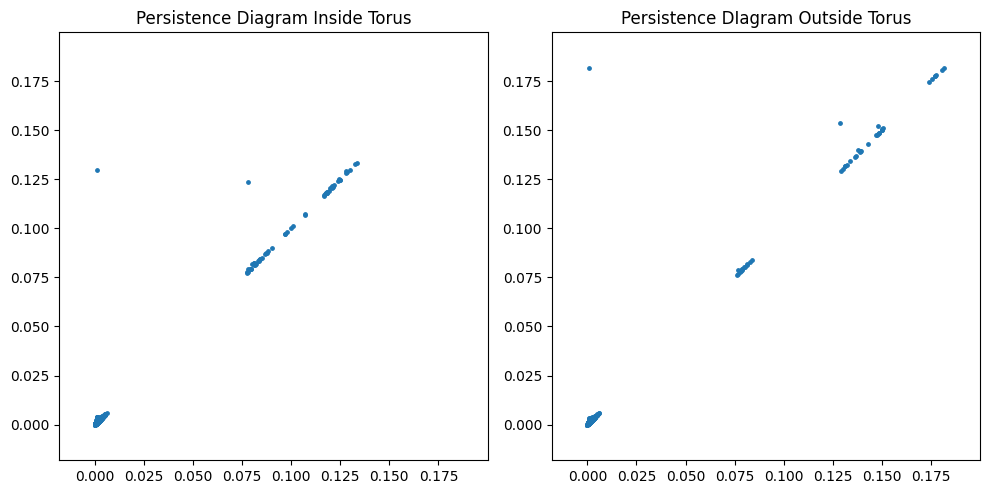

In [4]:
#Let us illustrate these sampling methods,
#as well as give an example of the persistence diagrams derived from 1-parameter persistence from each of the pairs of data sets.



n_points=600
in_points1, in_points2=sample_wrapped_classes(n_ellipse=n_points, n_torus=n_points, ellipsoid_radii=(0.2,  0.6,0.3), torus_radius=0.9,
    torus_thickness=0.02, shift_ellipsoid=False)

out_points1, out_points2=sample_wrapped_classes(n_ellipse=n_points, n_torus=n_points, ellipsoid_radii=(0.2,  0.6,0.3), torus_radius=0.9,
    torus_thickness=0.02, shift_ellipsoid=True)

plot_two_point_sets_3d(in_points1,  out_points1, in_points2, out_points2, titles=["Ellipsoid In Torus", "Ellipsoid Outside Torus"])



# Compute persistence diagram using Alpha complexesfiltration


def compute_PD(points):
  alpha = gd.AlphaComplex(points=points)
  st = alpha.create_simplex_tree()

  st.persistence()


  H1 = st.persistence_intervals_in_dimension(1)



  return H1



#points_3d = np.concatenate((points1, points2))
in_points=np.concatenate((in_points1, in_points2))
out_points=np.concatenate((out_points1, out_points2))

in_PD=compute_PD(in_points)
out_PD=compute_PD(out_points)

plot_two_point_sets(in_PD, out_PD, titles=["Persistence Diagram Inside Torus", "Persistence DIagram Outside Torus"])




In [5]:
#In practice, if the radii of the torus and ellipsoids are fixed, then shifting the ellipsoid from the center of the torus causes significant enough change
#in the persistence diagram in order for 1-parameter persistence to distinguish between the two sampling methods. Thus to make things harder,
#we will randomize the radii of both the torus and the ellipsoids in each of the samplings.

def rand_mix_pnts(n_points):
  rng = np.random.default_rng()

  er1 = rng.uniform(0.7,1)
  er2= rng.uniform(0.7,1)
  er3= rng.uniform(0.7,1)
  ellipsoid_radii=(er1, er2, er3)

  torus_radius=rng.uniform(2*max(er1,er2,er3), 2.5*max(er1,er2,er3))
  torus_thickness=rng.uniform(0.05,0.06)

  n_torus=math.ceil(5*n_points*torus_thickness*(torus_radius))
  n_ellipse=n_points-n_torus

  points1, points2=sample_wrapped_classes(n_ellipse=n_ellipse, n_torus=n_torus, ellipsoid_radii=ellipsoid_radii, torus_radius=torus_radius, torus_thickness=torus_thickness, shift_ellipsoid=False)

  return points1, points2



def rand_nomix_pnts(n_points):
  rng = np.random.default_rng()

  er1 = rng.uniform(0.7,1)
  er2= rng.uniform(0.7,1)
  er3= rng.uniform(0.7,1)
  ellipsoid_radii=(er1, er2, er3)

  torus_radius=rng.uniform(1.7*max(er1,er2,er3), 2.2*max(er1,er2,er3))
  torus_thickness=rng.uniform(0.05,0.06)

  n_torus=math.ceil(5*n_points*torus_thickness*(torus_radius))
  n_ellipse=n_points-n_torus

  points1, points2=sample_wrapped_classes(n_ellipse=n_ellipse, n_torus=n_torus, ellipsoid_radii=ellipsoid_radii, torus_radius=torus_radius, torus_thickness=torus_thickness, shift_ellipsoid=True)

  return points1, points2





Now let's sample points for our SVM experiment. We will sample 50 pairs of data sets for each of the methods above. We will first attempt to distinguish between them using 1-parameter persistence on the union of the two datasets in each pair. We will use peristence landscapes as a vectorization tool for this in an SVM experiment. After which, we will calculate mixup barcodes and use MPHvect in an SVM experiment.

In [6]:
#Sampling 50 pairs of data sets using each method.

Class_Inside=[]
Class_Outside=[]
n_points=500
iterations=50

for i in range(iterations):

  points1, points2=rand_mix_pnts(n_points)
  Class_Inside.append([points1, points2])

  points1, points2=rand_nomix_pnts(n_points)
  Class_Outside.append([points1, points2])



In [7]:
#Defining a single function to calculate persistence landscape for 1-parameter persistence


def compute_landscapes(points, num_layers=5, dmax=1, resolution=500):
  alpha = gd.AlphaComplex(points=points)
  st = alpha.create_simplex_tree()

  st.persistence()


  H1 = st.persistence_intervals_in_dimension(1)


  landscape=PersLandscapeApprox(dgms=[H1], hom_deg=0, start=0, stop=dmax, num_steps=resolution).values
  flat_landscape=landscape[:num_layers].flatten()
  return flat_landscape

In [8]:
#Generating Landscapes for each sampling method
Inside_Torus_Landscapes=[]
Outside_Torus_Landscapes=[]


for i in range(iterations):
  X=np.concatenate((Class_Inside[i][0], Class_Inside[i][1]))
  Y=np.concatenate((Class_Outside[i][0], Class_Outside[i][1]))

  Inside_Torus_Landscape = compute_landscapes(X)
  Outside_Torus_Landscape = compute_landscapes(Y)

  Inside_Torus_Landscapes.append(Inside_Torus_Landscape)
  Outside_Torus_Landscapes.append(Outside_Torus_Landscape)

  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()

Completed 50/50


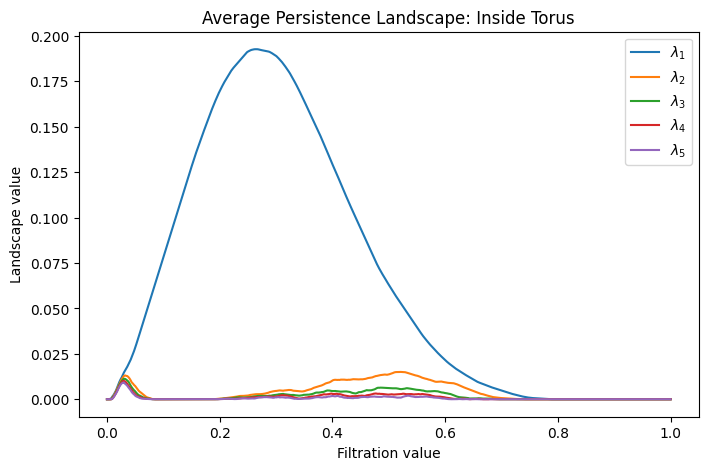

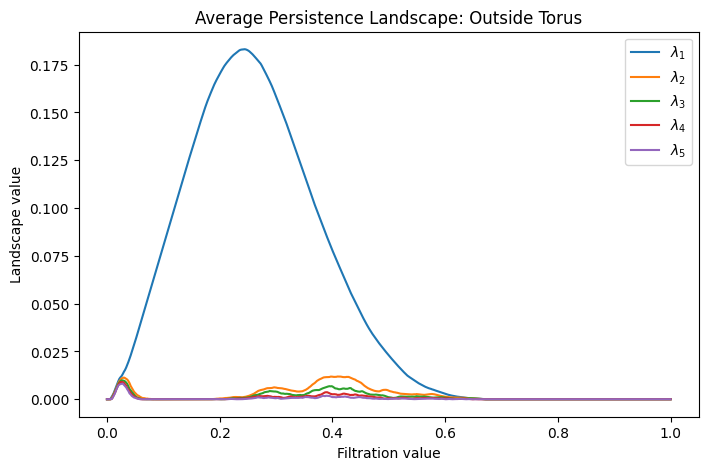

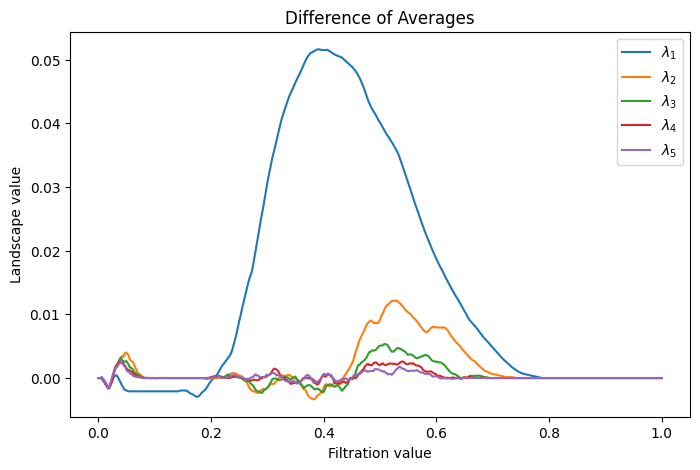

In [9]:
#Before attempting SVM on these vectors, we will visualize the average persistence landscape of each.

L_In_Torus_stack = np.vstack(Inside_Torus_Landscapes)
L_In_Torus_avg_flat = L_In_Torus_stack.mean(axis=0)
L_In_Torus_avg = L_In_Torus_avg_flat.reshape(5, 500)


bmin=0
dmax=1
t = np.linspace(bmin, dmax, 500)

plt.figure(figsize=(8,5))
for k in range(5):
    plt.plot(t, L_In_Torus_avg[k], label=rf"$\lambda_{k+1}$")

plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.title("Average Persistence Landscape: Inside Torus")
plt.legend()
plt.show()



L_Out_Torus_stack = np.vstack(Outside_Torus_Landscapes)

L_Out_Torus_avg_flat = L_Out_Torus_stack.mean(axis=0)

L_Out_Torus_avg = L_Out_Torus_avg_flat.reshape(5, 500)





plt.figure(figsize=(8,5))
for k in range(5):
    plt.plot(t, L_Out_Torus_avg[k], label=rf"$\lambda_{k+1}$")

plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.title("Average Persistence Landscape: Outside Torus")
plt.legend()
plt.show()

L_dif=L_In_Torus_avg-L_Out_Torus_avg



plt.figure(figsize=(8,5))
for k in range(5):
    plt.plot(t, L_dif[k], label=rf"$\lambda_{k+1}$")

plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.title("Difference of Averages")
plt.legend()
plt.show()

Observed accuracy: 0.6300
Permutation p-value: 0.0080


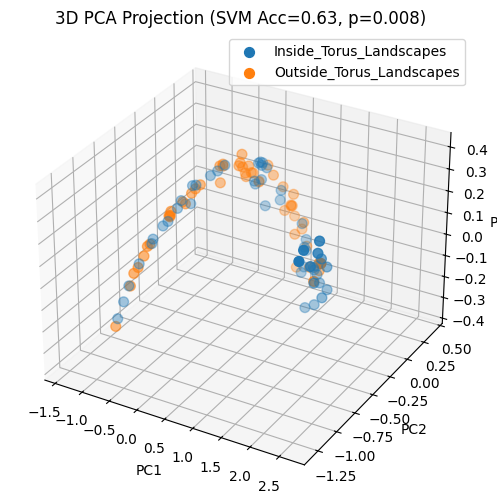

In [10]:
#We now attempt classification using Support Vector Machine. We also perform a permutation test and find the associated p-value.
#We then plot the 3D PCA projection of the Landscapes.
do_SVM_and_PCA(Inside_Torus_Landscapes, Outside_Torus_Landscapes, name_1="Inside_Torus_Landscapes", name_2="Outside_Torus_Landscapes")

Now let's try MPHvect on Mixup Barcodes with these classes of data. I made the function for calculating mixup barcodes with the help of Hubert Wagner. The rest of these functions are for sampling methods. Mixup barcodes are calcluated on an ordered pair of sets of data points. Mixup Barcodes track the change in lifespans of homological features based on whether or not persistent homology computations are done with or without one of the classes of data. Mixup Barcodes are collections of triples of the form (b, pd, d). b is the birth of a homological feature when 1-parameter persistence computations are done on the the first data set. d is the death of that feature, also only considering the first class of data. pd is the ``pre-death'' of that feature. It is the death of this feature under the inclusion map of the persistence module on just the first data set, into the persistence module on the union of the two data sets.

In [11]:


def Calculate_Mixup(points1, points2):
  points=np.vstack((points1, points2))

  labels1 = [0 for _ in range(len(points1))]
  labels2=  [1 for _ in range(len(points2))]
  labels=labels1+labels2

  alpha = ChromaticAlphaComplex(points=points, labels=labels)
  del points, labels

  simplicial_complex = alpha.get_simplicial_complex(sub_complex='0')
  del alpha

  simplicial_complex.compute_persistence()
  feature_extractor = chro.experimental.feature_extraction.FeatureExtractor(simplicial_complex)

  sub_pairs = feature_extractor.persistence_pairs(group='sub_complex', dim=1, sorted_by='persistence')
  im_pairs = feature_extractor.persistence_pairs(group='image', dim=1, sorted_by='persistence')
  im_dth = dict(im_pairs)
  del im_pairs

  w = simplicial_complex.weight_function
  n = len(sub_pairs)
  mixup_barcode = np.empty((n, 3), dtype=np.float32)

  for i, (b, d) in enumerate(sub_pairs):
      wb = w(b)
      wd = w(d)

      if b in im_dth:
          mixup_barcode[i, 0] = wb
          mixup_barcode[i, 1] = w(im_dth[b])
          mixup_barcode[i, 2] = wd
      else:
          mixup_barcode[i, 0] = wb
          mixup_barcode[i, 1] = wd
          mixup_barcode[i, 2] = wd


  del sub_pairs, im_dth, feature_extractor, simplicial_complex
  gc.collect()

  return mixup_barcode






In [12]:
#First we calculate mixup barcodes, which tracks the change in lifespans of homological features when the class of the data points in the ellipsoid is included in the set of data points of the torus.
#These features take the form of collections of triples of the form (b, pd, d). b is the birth of a homological feature in the data set contained in the torus. d is the death of that feature (in the standard 1-parameter persistence sesnse).
#pd is the ``pre-death'' of that feature. It is the death of this feature if we ran the simplicial complex filtration on the union of the data from the torus AND the ellipsoid.
#calculating mixup barcodes takes about 1 minute, 30 seconds per iteration

Inside_Mixup=[]
Outside_Mixup=[]
for i in range(iterations):
  inside_ellip=Class_Inside[i][0]
  inside_ann=Class_Inside[i][1]
  in_mixup = Calculate_Mixup(inside_ann, inside_ellip)

  outside_ellip=Class_Outside[i][0]
  outside_ann=Class_Outside[i][1]
  out_mixup = Calculate_Mixup(outside_ann, outside_ellip)

  Inside_Mixup.append(in_mixup)
  Outside_Mixup.append(out_mixup)
  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()



Completed 50/50


In [13]:
#normalize mixup barcodes to fit into unit cube. MPHvect requires all coordinates of barcodes/diagrams to be between 0 and 1,
#with more efficiency if the maximum coordinate is close to 1.

max_inside=max([arr[2] for arr in Inside_Mixup[0]])
max_outside=max([arr[2] for arr in Outside_Mixup[0]])
my_max=max(max_inside, max_outside)

print("max before normalization:" , my_max)

Normed_Inside_Mixup=np.array([None for _ in range(iterations)])
Normed_Outside_Mixup=np.array([None for _ in range(iterations)])

for i in range(iterations):
  in_mixup=Inside_Mixup[i]
  out_mixup=Outside_Mixup[i]

  normed_inside=my_max**(-1)*in_mixup
  normed_outside=my_max**(-1)*out_mixup

  Normed_Inside_Mixup[i]=normed_inside
  Normed_Outside_Mixup[i]=normed_outside


print("max after normalization:" ,max([arr[2] for arr in Normed_Inside_Mixup[0]]))


max before normalization: 2.2366202
max after normalization: 1.0


Let's visualize one of these mixup barcodes. Recall such a barcode is a collection of triples (b,pd,d), where b <=pd<=d. Furthermore, the "mixup" of a points/feature is defined as d-pd. We can first plot a mixup barcode as double-intervals [b,pd), [pd,d) .

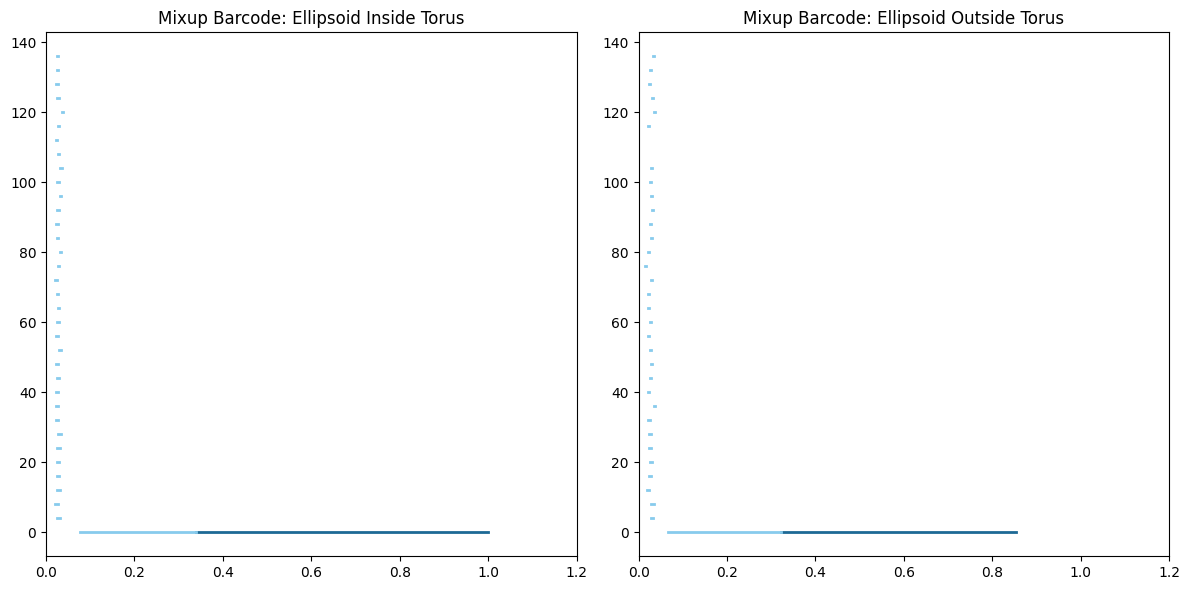

In [14]:
my_mixup_barcode_inside=Normed_Inside_Mixup[0]
my_mixup_barcode_outside=Normed_Outside_Mixup[0]

color1=(136/256,204/256,238/256)
color2=(29/256,105/256,150/256)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns


for i, (a, b, c) in enumerate(my_mixup_barcode_inside):
    if i < 35:
        axes[0].plot([b, c], [4*i, 4*i], lw=2, c=color2)
        axes[0].plot([a, b], [4*i, 4*i], lw=2, c=color1)

axes[0].set_title("Mixup Barcode: Ellipsoid Inside Torus")



for i, (a, b, c) in enumerate(my_mixup_barcode_outside):
    if i < 35:
        axes[1].plot([b, c], [4*i, 4*i], lw=2, c=color2)
        axes[1].plot([a, b], [4*i, 4*i], lw=2, c=color1)

axes[1].set_title("Mixup Barcode: Ellipsoid Outside Torus")

xmin = 0
xmax = 1.2

axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)
plt.tight_layout()
plt.show()

MPHvect takes each collection of such triples and maps them to a single vector in ell_1. We can get an intuitive idea of where the magnitude of this vector comes from by the following method. This is called the "Mixup Nailbed". In essence, we treat each point of the mixup barcode as a point in R^3, akin to a "mixup diagram". We then treat each point of such a diagram as its own mixup diagram, rather than the collection of points entirely being considered as one diagram. That is, we apply MPHvect to each point individually. Thus, we yield a vector in ell_1 for each point of the diagram. We then plot these points of the diagram and their associated vectors in the 3d plot below. Each red point is a point of the mixup diagram, and each color coded line segment has section lengths equal to the entries of the corresponding vector for that point of the diagram. We've highlighted the plane of no mixup (i.e. x_2=x_3). Note that most of the points of the diagram in these examples have little to no mixup, and are thus mapped to the 0 vector with MPHvect.


In [15]:
#set up vectorization: MPHvect generates a list of functionals that are part of a Schauder basis derived from refinements of the Coxeter Freudenthal Kuhn triangulation of R^d.
#We choose how many of these refinements to calculate in practice (in this example, three refinements), with more refinements yielding more accuracy, but requiring more compute time.
#The inputs: dim is the number of parameters for which we are using persistence homology (i.e. 1-parameter persistence): max layer is the maximal number of refinements we take of the Coxeter Freudenthal Kuhn triangulation
#we take in order to define our subset of the associated Schauder Basis. min_layer is the first refinement we consider in our construction of such a subset of funcitonals.


n_list, p_list=collect_vertices_mixup(4)


vectorizations=[None for _ in range(len(my_mixup_barcode_inside))]

for i,point in enumerate(my_mixup_barcode_inside):
  vector=vectorize_fast(n_list, p_list, np.array([point]), [1])
  vectorizations[i]=vector


plot_mixup_nailbed(my_mixup_barcode_inside, vectorizations)

#Now the same for the example where the ellipsoid is shifted out of the torus

vectorizations=[None for _ in range(len(my_mixup_barcode_outside))]

for i,point in enumerate(my_mixup_barcode_outside):
  vector=vectorize_fast(n_list, p_list, np.array([point]), [1])
  vectorizations[i]=vector


plot_mixup_nailbed(my_mixup_barcode_outside, vectorizations)

#In this example, there is one significant feature that has a large difference between death and pre-death. This is represented as the single poitn off the plane x_2=x_3. The colored line segments erupting from this point, have lengths corresponding to the values in the vectorization of that point.
#For example, if a point was mapped to the vector [2,1,0.5,0], then we would see three, differently colored line segments erupting from the point, with lengths equal to 2,1,and 0.5 respectively.
#Points with no mixup (pre-death=death) are mapped to the 0 vector in our method. This is a choice and we could make it such that the only points that are mapped to the 0 vector are those such that b=pd=d.


Output hidden; open in https://colab.research.google.com to view.

Now let's vectorize all the mixup barcodes. This converts each mixup barcode to a list of real numbers.

In [16]:
n_list, p_list=collect_vertices_mixup(4)


Inside_Vectors=[]
Outside_Vectors=[]


for i in range(iterations):
  in_mixup=Normed_Inside_Mixup[i]
  out_mixup=Normed_Outside_Mixup[i]

  mults=[1 for _ in range(len(in_mixup))]
  in_vec = vectorize_fast(n_list, p_list, in_mixup, mults)

  mults=[1 for _ in range(len(out_mixup))]
  out_vec = vectorize_fast(n_list, p_list, out_mixup, mults)
  Inside_Vectors.append(in_vec)
  Outside_Vectors.append(out_vec)

  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()

Completed 50/50


Observed accuracy: 0.9500
Permutation p-value: 0.0000


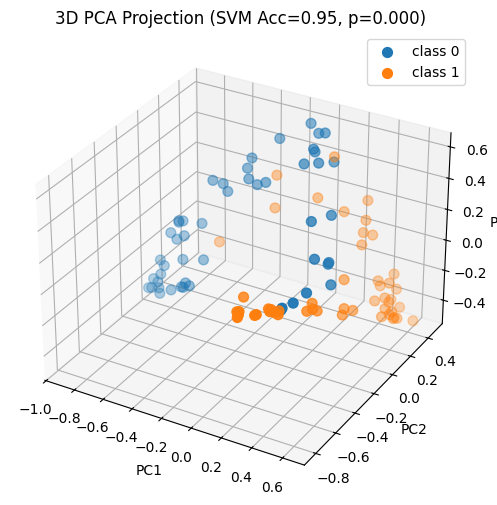

In [17]:
#Now we attempt to classify these 2 groups of 50 vectors each using SVM. We do a permutation test with 1000 permutations and calculate a p-value. Finally, we plot the PCA projection onto 3 components.
do_SVM_and_PCA(Inside_Vectors, Outside_Vectors)